<a href="https://colab.research.google.com/github/jooha-yoo/data-pipeline/blob/main/DATA202_Midterm_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b> DATA202 Midterm Project </b>
-  Ben Kosters, bak32@calvin.edu <br>
- Hannah Yoo, jy49@calvin.edu


<h1><b>Data</b></h1>

The dataset examines [**social networking site usage and mental health problems among young adults in Bangladesh**](https://pmc.ncbi.nlm.nih.gov/articles/PMC8627992/#_ad93_). It was collected by the National Institute of Health (NIH), a reputable U.S. medical research agency under the Department of Health and Human Services. <br> <br>
**Dataset credibility:**

- The source documentation describes the experimental design, including what biases researchers considered (and potentially overlooked)
- Mental health measurements use clinically validated scales with proper citations
- Data collection methods are transparent

**Methodology:**

- Population: Bangladeshis aged 15-40 with social media accounts
- Sample size: 791 valid responses (826 collected, 35 excluded for incomplete data)
- Collection method: Google Forms with multiple-choice questions
  - Strength: Produces clean, analyzable data
  - Limitation: Restricts nuanced responses



**Important context:**

- Data was collected during the COVID-19 pandemic, which the researchers acknowledge as a confounding factor affecting mental health independently
- The pandemic's mental health impacts are documented but separate from social media effects

**Key limitations:**

1. Geographic specificity: Findings apply to young adults in Bangladesh and cannot be generalized globally. Cultural norms, technology access, and social media perspectives vary significantly across populations, though similar trends may exist elsewhere.
2. Bidirectional causality: The relationship between social media use and mental health is complex:

      - Does heavy social media use cause poor mental health?
      - Or do people with existing mental health problems use social media more?
      - Likely both create feedback loops that this cross-sectional study cannot untangle
  <br>

<h2><b>Motivation</b></h2>

We chose this topic because social media's mental health impacts have gained significant attention recently, and as members of the younger generation, we're directly affected by these platforms. <br> <br>
As Christian computer science students, we have a unique responsibility to examine technology holistically—acknowledging both its benefits and harms. We're called to be agents of renewal in our field, which means critically examining how innovations like social media shape human flourishing. Rather than ignoring these effects or accepting them uncritically, we aim to understand and share these findings with others.

<h2><b>Claim</b></h>

The source claims "based on the present dataset, it is difficult to conclude whether the mental health of the young Bangladeshi population is affected by the use of SNS or the COVID-19 pandemic." While mental health is very complex and influenced by many factors, we claim that there is an effect of social media usage on mental health and will generate a few visualizations to explore this claim.

<h1><b> Wrangling </h1></b>

**Wrangling for all graphs: Column cleaning and renaming**
- Removed timestamp (seemed irrelevant for the graph for now)
- Renamed all columns with column_mapping for clarity



In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_excel("mmc2.xlsx")

column_mapping = {
    # Social Media Use & Demographics
    "1. Do you have a social media account? (e.g., Facebook, Twitter, etc.)": "has_sns_account",
    "2. Which social media account do you use usually?": "sns_platform_main",
    "3. Which device do you usually use to connect social media?": "sns_device",
    "4. Which type of internet connection do you use?": "internet_type",
    "5. How long have you been using a social media account?": "sns_years_use",
    "6. How frequently do you post (upload status or add photos/videos) on social media?": "sns_post_freq",
    "7. How much time do you spend daily in social media?": "sns_hours_per_day",
    "8. When do you usually use social media?": "sns_usage_time",
    "9. How many friends do you have on social media?": "sns_num_friends",
    "10. How many friends do you know personally in social media?": "sns_num_real_friends",
    "11. How many groups you are tagged in social media?": "sns_num_groups",
    "12. What is your main purpose for using social media (e.g. Facebook)?": "sns_main_purpose",
    "13. What contents do you mainly look for in your social media news feed?": "sns_content_type",
    "14.Do you believe social media is a good thing?": "sns_belief_good",
    "15. When you see something in social media, do you instantly believe it?": "sns_instant_belief",
    "16. Have you ever experienced peer pressure due to social media?": "sns_peer_pressure",
    "17. Does your emotion get influenced by other's posts (success, failure, loss)?": "sns_emotion_influence",
    "18. Have you ever compared yourself with other’s success or luxurious life?": "sns_self_comparison",
    "19. Do you think, your mental wellbeing would be better if you do not use social media?": "sns_wellbeing_better_without",
    "20. If answer is yes, are you trying to control that thing and trying to reduce the use of social media?": "sns_reduce_use_attempt",
    "21. Please write your age in years (number).": "age",
    "22. Gender": "gender",
    "23. Marital Status": "marital_status",
    "24. Religion": "religion",
    "25. Education": "education",
    "26. Profession": "profession",
    "27. Monthly income": "monthly_income",
    "28. Area of residence": "residence_area",
    "29. Living with-": "living_with",
    "30. Body weight (Kg)": "weight_kg",
    "31. Height (m)": "height_m",
    "32. Smoking habit": "smoking_habit",

    # UCLA Loneliness Scale (UCLA-8)
    "1. In the past 30 days, do you feel lack of companionship?": "ucla_lack_companionship",
    "2. In the past 30 days, there is no one I can turn to": "ucla_no_one_turn_to",
    "3. In the past 30 days, I feel left out.": "ucla_left_out",
    "4. In the last 30 days, I feel isolated from others.": "ucla_isolated",
    "5. In the last 30 days, I am unhappy being so withdrawn.": "ucla_unhappy_withdrawn",
    "6. In the last 30 days, people are around me but not with me.": "ucla_people_around_not_with",
    "7. In the last 30 days, I am an outgoing person.": "ucla_outgoing",
    "8. In the last 30 days, I can find companionship when I want it.": "ucla_find_companionship",

    # PHQ-9 Depression Scale
    "1 In the last 30 days, little interest or pleasure in doing things.": "phq9_interest_pleasure",
    "2. In the last 30 days, feeling down, depressed or hopeless.": "phq9_feeling_down",
    "3. In the last 30 days, trouble falling or staying asleep, sleeping too much": "phq9_sleep_trouble",
    "4. In the last 30 days, Feeling tired or having little energy.": "phq9_low_energy",
    "5. In the last 30 days, poor appetite or over-eating.": "phq9_appetite_change",
    "6. In the last 30 days, feeling bad about yourself-or that you are a failure or have let yourself or your family down.": "phq9_self_esteem",
    "7. In the last 30 days, trouble concentrating on things, such as reading the newspaper or watching television.": "phq9_concentration",
    "8. In the last 30 days, moving or speaking so slowly or the opposite-moving around a lot more than usual.": "phq9_psychomotor_change",
    "9. In the last 30 days, thoughts that you would be better off dead, or of hurting yourself.": "phq9_suicidal_thoughts",

    # GAD-7 Anxiety Scale
    "1. In the last 30 days, I am feeling nervous, anxious, or on edge": "gad7_nervous",
    "2. In the last 30 days, I an not being able to stop or control worrying": "gad7_cannot_control_worry",
    "3. In the last 30 days, I am worrying too much about different things.": "gad7_worry_too_much",
    "4. In the last 30 days, I felt trouble in relaxing.": "gad7_trouble_relaxing",
    "5. In the last 30 days, I am being so restless that it's hard to sit still": "gad7_restless",
    "6. In the last 30 days, I becoming easily annoyed or irritable.": "gad7_irritable",
    "7. In the last 30 days, I am feeling afraid as if something awful might happen.": "gad7_afraid",

    # PSQI Sleep Quality
    "1. When I am usually gone to bed?": "sleep_bedtime",
    "2. How long (in minutes) has it taken you to fall asleep each night?": "sleep_latency_min",
    "3. When have you usually gotten up in the morning?": "sleep_wake_time",
    "4. How many hours of actual sleep do you get at night?": "sleep_hours",
    "5. How many hours were you in bed?": "sleep_time_in_bed",
    "6. In last 30 days, How many times, I cannot get to sleep within 30 minutes?": "sleep_cannot_sleep_30min_freq",
    "7. In last 30 days, How many times, I wake up in the middle of the night or early morning?": "sleep_midnight_wakeup_freq",
    "8. In last 30 days, How many times, I had to get up to use the bathroom?": "sleep_bathroom_freq",
    "9. In last 30 days, How many times, I cannot breathe comfortably?": "sleep_breath_discomfort_freq",
    "10. In last 30 days, How many times, I cough or snore loudly?": "sleep_snore_freq",
    "11. In last 30 days, How many times, I feel too cold?": "sleep_cold_freq",
    "12. In last 30 days, How many times, I feel too hot?": "sleep_hot_freq",
    "13. In last 30 days, How many times, I saw bad dreams?": "sleep_bad_dreams_freq",
    "14. In last 30 days, How many times, I have pain during sleep?": "sleep_pain_freq",
    "15. In last 30 days, How many times, I having trouble sleeping for any other reason?": "sleep_trouble_other_freq",
    "16. In last 30 days, In last month, have you take medicines for sleep?": "sleep_med_use",
    "17. In last month, how many times you cannot sleep due to any program or other important case?": "sleep_missed_due_program_freq",
    "18. In last month, how many times you face problems to maintain program or other important case?": "sleep_daytime_problem_freq",
    "19. During the past month, how would you rate your sleep quality overall?": "sleep_quality_rating"
}

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\xa0', '', regex=True)
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)

df = df.rename(columns=column_mapping)

# Remove timestamp
df = df.drop(columns=["Timestamp"])

# pd.set_option('display.max_columns', None)
# df.head()



<h1><b>Graph 1: Mental Health Indexes and Social Media Usage</b></h1>

**Wrangling: Mental Health Indexes** <br>

- To compare the UCLA Loneliness Scale, PHQ-9 Depression Scale, and the GAD-7 Anxiety Scale, we convert all responses for each test to one single value per test

- Each survey has questions set up that can correspond to values between 0 and 3, where 0 corresponds to low/no symptoms of the mental health dimension, and 3 corresponds to a high symptom

- The loneliness index requires more wrangling than the other indexes. Becuase of the wording, the same answer could mean a positive correlation with loneliness or a negative correlation. For example, if a submitter answers "Often" to the question “In the past 30 days, do you feel lack of companionship?”, this is a positive association with loneliness. However, if "Often" is the answer to the question "I am an outoging person", this is correlated with less loneliness.

- By aggregating these survey metrics into a single value, we can more easily compare results across these survey tests

- Because each test as a different number of questions, we can take the mean value of responses compare values across tests

- A result closer to 3 will indicate a high presence of the mental health issue, while a value closer to 0 will indicate a lower presence of the mental health issue

In [ ]:

loneliness_cols = [
    "ucla_lack_companionship",
    "ucla_no_one_turn_to",
    "ucla_left_out",
    "ucla_isolated",
    "ucla_unhappy_withdrawn",
    "ucla_people_around_not_with",
    "ucla_outgoing",
    "ucla_find_companionship"
]

# For testing to make sure there are no unexpected values
# for col in loneliness_cols:
#     print(f"\nDistribution for {col}:")
#     print(df[col].value_counts())

#Questions where "Often" is associated with more loneliness
positive_cols = [
    "ucla_lack_companionship",
    "ucla_no_one_turn_to",
    "ucla_left_out",
    "ucla_isolated",
    "ucla_unhappy_withdrawn", "ucla_people_around_not_with"]

# Questions where Often is associated with less loneliness
negative_cols = ["ucla_outgoing",
    "ucla_find_companionship"]

lone_map = {
    "Never" : 0,
    "Rarely" : 1,
    "Sometimes" : 2,
    "Often" : 3
}

composite_scores = df.copy()

# Apply the mapping for all loneliness-related columns
for col in positive_cols + negative_cols:
    composite_scores[col] = composite_scores[col].map(lone_map)

# Reverse-code the negatively worded items so that higher = more loneliness
# This section of code was generated with AI
for col in negative_cols:
    composite_scores[col] = composite_scores[col].apply(lambda x: 3 - x if pd.notnull(x) else x)

# Compute the mean loneliness index --> keep scale between 0 and 3
composite_scores["loneliness_index"] = composite_scores[positive_cols + negative_cols].mean(axis=1)

# Optional: check the distribution
print(composite_scores["loneliness_index"].describe())

count    791.000000
mean       1.278603
std        0.621089
min        0.000000
25%        0.750000
50%        1.250000
75%        1.750000
max        3.000000
Name: loneliness_index, dtype: float64


In [ ]:
phq9 = ["phq9_interest_pleasure", "phq9_feeling_down","phq9_sleep_trouble", "phq9_low_energy", "phq9_appetite_change", "phq9_self_esteem", "phq9_concentration", "phq9_psychomotor_change", "phq9_suicidal_thoughts"]

# For testing to make sure there are no unexpected values
# for col in phq9:
#     print(f"\nDistribution for {col}:")
#     print(df[col].value_counts())

depression_scale = {
  "Not at all": 0,
  "Several days": 1,
  "Nearly everyday": 2,
  "Half of days": 3
}

for col in phq9:
  composite_scores[col] = composite_scores[col].map(depression_scale)

# Compute the mean depression index and multiply by 3 to scale it to 0-9
composite_scores["depression_index"] = composite_scores[phq9].mean(axis=1)

print(composite_scores["depression_index"].describe())

count    791.000000
mean       0.959685
std        0.631007
min        0.000000
25%        0.444444
50%        0.888889
75%        1.444444
max        3.000000
Name: depression_index, dtype: float64


In [ ]:
gad7 = ["gad7_nervous","gad7_cannot_control_worry","gad7_worry_too_much","gad7_trouble_relaxing","gad7_restless","gad7_irritable","gad7_afraid",]

anxiety_scale = {
  "Not at all": 0,
  "Several days": 1,
  "Nearly everyday": 2,
  "Half of days": 3
}

for col in gad7:
  composite_scores[col] = composite_scores[col].map(anxiety_scale)

composite_scores["anxiety_index"] = composite_scores[gad7].mean(axis=1)

print(composite_scores["anxiety_index"].describe())


count    785.000000
mean       0.787343
std        0.611454
min        0.000000
25%        0.285714
50%        0.750000
75%        1.000000
max        2.000000
Name: anxiety_index, dtype: float64


In [ ]:
import plotly.graph_objects as go

# Properly order string categories
sns_hours_order = ["Less than 1 hour", "1-3 hours", "3-5 hours", "More than 5 hours"]
composite_scores["sns_hours_per_day"] = pd.Categorical(
    composite_scores["sns_hours_per_day"],
    categories=sns_hours_order,
    ordered=True
)

summary = (
    composite_scores.groupby("sns_hours_per_day", observed=True)[
        ["loneliness_index", "anxiety_index", "depression_index"]
    ]
    .median()
    .reset_index()
)

fig = go.Figure()

for metric in ["loneliness_index", "anxiety_index", "depression_index"]:
    fig.add_trace(go.Bar(
        x=summary["sns_hours_per_day"],
        y=summary[metric],
        name=metric.replace("_index", "").capitalize(),
        text=summary[metric].round(2),           # show numbers (rounded)
        textposition="outside",                  # place text above bars
    ))

fig.update_layout(
    title="Average Mental Health Index by Daily Social Media Usage",
    xaxis_title="Daily Social Media Usage",
    yaxis_title="Average Index (0–3)",
    barmode="group",
    template="plotly_white",
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)

fig.show()



# What this visualizations tell us:
**Primary finding**:

- There is a slight dip in loneliness between people who use social media less than 1 hour and between 1 and 3 hours. Anxiety and Depression remain constant. However, after 3 hours or more of social media use, all three of these indexes rise.

**Secondary observations:**
- The loneliness index is higher than other mental health indexes for all groups of social media usage

**Conclusions**

- While we cannot prove that extended social media usage increases symptoms of poor mental health, we can see that there is a general trend that as social media usage increases, the indexes of the mental health indicators rises among the sample. loneliness is much higher than the other indexes, which we may contribute to the Covid-19 pandemic as people were more isolated during that time.

**Important limitations:**

- By aggregating all questions in a test to one aggregate value, we lose out on the granularity of the individual questions. There may be a particular question that skews answers in one directon or another that we cannot see.

- Since we are further aggregating the scores of all people into one value, we cannot see any potential outliers. Depression, anxiety, and loneliness are very serious issues and there may be people who truely need help but are hidden by everyone else.

- Like the future graphs, we cannot determine causation from these results.



<h1><b> Graph 2: Sleep Quality and Social Media Usage </h1></b>



We also want to examine the correlation between longer period of usage of social media users resulting in worse sleep quality and shorter sleep duration. <br>
**Wrangling: Wrangling Mental Health Indexes** <br>
- The data wrangling below shows the distribution of social media hours and sleep hours reported by the participants.

In [ ]:
# Data Wrangling
print("Social Media Hours Distribution:")
print(df['sns_hours_per_day'].value_counts())

print("\nSleep Hours Distribution:")
print(df['sleep_hours'].value_counts())

# Check overall "Very bad" percentage
total = len(df)
very_bad = len(df[df['sleep_quality_rating'] == 'Very bad'])
print(f"\nVery bad sleep quality: {very_bad}/{total} = {very_bad/total*100:.1f}%")

Social Media Hours Distribution:
sns_hours_per_day
1-3 hours            291
3-5 hours            204
More than 5 hours    176
Less than 1 hour     120
Name: count, dtype: int64

Sleep Hours Distribution:
sleep_hours
4-6 hours            440
7-8 hours            254
Less than 4 hours     64
More than 8 hours     33
Name: count, dtype: int64

Very bad sleep quality: 86/791 = 10.9%


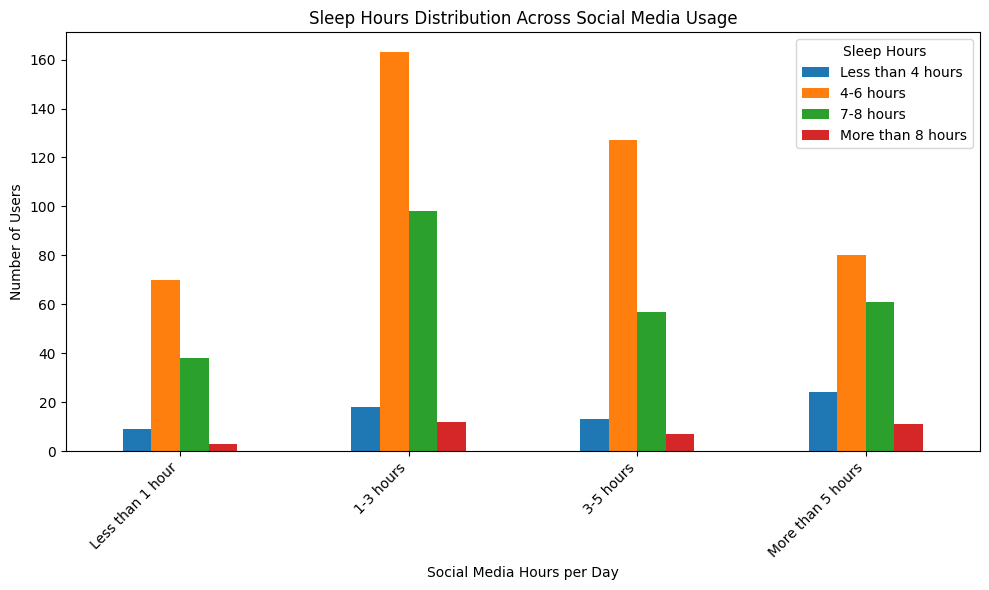

In [ ]:
import matplotlib.pyplot as plt
# generated with the help of AI
# order the categories (without this, it would be categorized randomly and create confusion while visualizing)
sns_hours_order = ['Less than 1 hour', '1-3 hours', '3-5 hours', 'More than 5 hours']
sleep_hours_order = ['Less than 4 hours', '4-6 hours', '7-8 hours', 'More than 8 hours']

count_data = pd.crosstab(
    df['sns_hours_per_day'],
    df['sleep_hours']
)

# Reorder the rows and columns
count_data = count_data.reindex(index=sns_hours_order, columns=sleep_hours_order)

count_data.plot(kind='bar', figsize=(10, 6), stacked=False) #side by side bard

plt.title("Sleep Hours Distribution Across Social Media Usage")
plt.xlabel("Social Media Hours per Day")
plt.ylabel("Number of Users")
plt.legend(title="Sleep Hours")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The graph above is not the best for visualization as it takes time to analyze in depth (each users who fall under the category of 'less than 1 hour' and from there, divided into categories of 4 different sleep hours). And also, it mostly shows distribution (how many people are in each category), but it doesn't show sleep quality at all. It just shows "163 people use social media 1-3 hours and sleep 4-6 hours". We could conclude and make basic assumptions about patterns for users with bigger 'Sleep Hours' scale tend to have lower 'SMS Hours per day'. However, that would be misleading. Thus, data wrangling is needed once again. This one specifically is to calculate the percentage of "Very bad" sleep quality depending on social media usage.

In [ ]:
print("% reporting 'Very bad' sleep quality by SNS usage:\n")
for sns in ['Less than 1 hour', '1-3 hours', '3-5 hours', 'More than 5 hours']:
    subset = df[df['sns_hours_per_day'] == sns]
    total = len(subset)
    very_bad = len(subset[subset['sleep_quality_rating'] == 'Very bad'])
    pct = (very_bad / total * 100) if total > 0 else 0
    print(f"{sns:20}: {pct:5.1f}% ({very_bad}/{total})")

# Also check all quality levels, not just "Very bad"
print("\n" + "="*60)
print("Full sleep quality distribution by SNS usage:")
print("="*60)
quality_crosstab = pd.crosstab(
    df['sns_hours_per_day'],
    df['sleep_quality_rating'],
    normalize='index'
) * 100
print(quality_crosstab.round(1))

% reporting 'Very bad' sleep quality by SNS usage:

Less than 1 hour    :   8.5% (10/118)
1-3 hours           :   9.5% (27/284)
3-5 hours           :  10.4% (21/202)
More than 5 hours   :  16.1% (28/174)

Full sleep quality distribution by SNS usage:
sleep_quality_rating  Farely bad  Farely good  Very bad  Very good
sns_hours_per_day                                                 
1-3 hours                   13.4         51.1       9.5       26.1
3-5 hours                   11.9         50.0      10.4       27.7
Less than 1 hour            11.0         50.0       8.5       30.5
More than 5 hours           20.7         39.1      16.1       24.1


-- Finalized graph -- <br>
The graph below includes the sleep quality rating too. The graph above presented sleep hours distribution across social media, however it did not conclude on much details. Including the sleep quality rating would support the strong point of how sleep hours, sleep rating really affects people who use social media and how many hours they use it.The graph below is the result after data wrangling the sleep quality rating part.

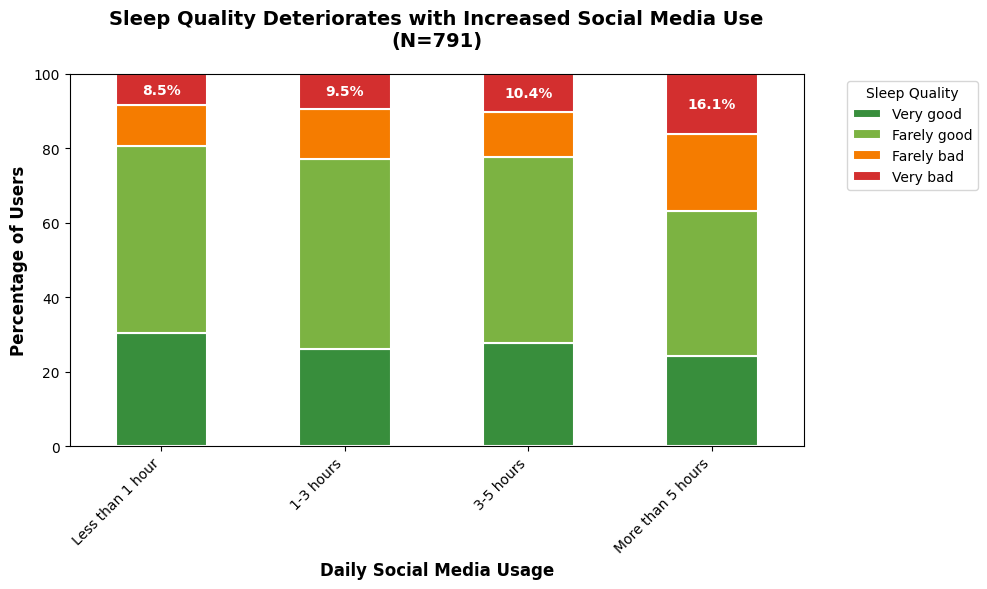

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

sns_order = ['Less than 1 hour', '1-3 hours', '3-5 hours', 'More than 5 hours']
quality_order = ['Very good', 'Farely good', 'Farely bad', 'Very bad']

# Get the crosstab data (percentages)
quality_dist = pd.crosstab(
    df['sns_hours_per_day'],
    df['sleep_quality_rating'],
    normalize='index'
) * 100

# Reorder
quality_dist = quality_dist.reindex(sns_order)[quality_order]

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

quality_dist.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#388e3c', '#7cb342', '#f57c00', '#d32f2f'],
    edgecolor='white',
    linewidth=1.5
)

plt.title('Sleep Quality Deteriorates with Increased Social Media Use\n(N=791)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Daily Social Media Usage', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Users', fontsize=12, fontweight='bold')
plt.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()

# Add percentage labels for "Very bad" category for emphasis on our point
for i, sns_cat in enumerate(sns_order):
    very_bad_pct = quality_dist.loc[sns_cat, 'Very bad']
    # Position at top of red section
    y_position = 100 - (very_bad_pct / 2)
    ax.text(i, y_position, f'{very_bad_pct:.1f}%',
            ha='center', va='center', fontweight='bold', color='white', fontsize=10)

plt.show()

# What this visualizations of Graph 2 tell us:
**Primary finding**:
- The percentage of people who reported "Very Bad" sleep quality (shown in red) increases consistently as daily social media usage rises. Light users (< 1 hr) reports 8.5% "Very Bad" sleep, while heavy users (5+ hours) report 16.1%- nearly double the rate.

**Secondary observations:**
- Users with 5+ hours of daily social media use show the highest proportion of "Fairly Bad" sleep quality at 20.7%- almost double that of light users of 10.8%.
- "Fairly Good" sleep quality (shown in light green) drops from 50% among light users to just 38.6% among heavy users.

# Conclusions we can draw:
**There is a clear association between increased social media usage and deteriorating sleep quality. As usage increases from less than 1 hour to more than 5 hours daily:**

- Poor sleep quality (combining "Fairly Bad" + "Very Bad") rises from 19.1% to 36.4%
- Good sleep quality (combining "Fairly Good" + "Very Good") drops from 80.8% to 63.6%

**Important limitations:**

- This correlation does not prove causation- we cannot determine whether heavy social media use causes poor sleep, or whether people with existing sleep problems tend to use social media more (perhaps because they're awake at night).
Other factors not captured in this analysis (age, mental health, work schedules, screen time from non-social media sources) may contribute to both increased social media use and poor sleep quality.



<h1><b>Graph 3: Social Media and Employment Status</b></h1>

We're trying to see correlation between employment status and if that affects the relationship between how much people use soical media or not.  <br>
**Wrangling: wrangling employment status data**
- Through the process of cleaning up job data, we found some rows (like profession) were not as clean or descriptive as we thought they were. We had initially wanted to explore the relationship between employment and stress levels, as there may be some correlation there. However, there is an important distinction between students and unemployed adults, but this dataset had already lumped students together with those who were unemployed.

In [ ]:
df['profession'] = df['profession'].str.strip()

df['profession'] = df['profession'].replace(['Bekar', 'bekar','Unemployed including students','Student', 'Used to work and now searching for job.',
                                          'No', 'I don\'t wanna do any job'], 'Unemployed including students')
df['profession'] = df['profession'].replace(['Housemaker', 'housemaker', 'homemaker'], 'Homemaker')
df['profession'] = df['profession'].replace(['Hhousewife', 'housewife', 'House wife', 'Recently unemployed, now housewife'], 'Housewife')
df['profession'] = df['profession'].replace(['doctor'], 'Doctor')

# Group by employment - either employed or unemployed
unemployed_professions = ['Unemployed including students']
df['employment_status'] = np.where(df['profession'].isin(unemployed_professions), 'Unemployed including students', 'Employed')



In [ ]:
import plotly.express as px
import pandas as pd

# First, create employment_status from profession
df['employment_status'] = df['profession'].apply(
    lambda x: 'Unemployed' if 'Unemployed' in str(x) or 'student' in str(x).lower()
    else 'Employed'
)

# Count users by SNS usage and employment status
count_data = df.groupby(['sns_hours_per_day', 'employment_status']).size().reset_index(name='count')

# Create grouped bar chart
fig = px.bar(
    count_data,
    x="sns_hours_per_day",
    y="count",
    color="employment_status",
    barmode='group',  # Side-by-side bars
    title="Social Media Usage by Employment Status",
    category_orders={"sns_hours_per_day": ['Less than 1 hour', '1-3 hours', '3-5 hours', 'More than 5 hours']},
    color_discrete_map={'Employed': '#2563eb', 'Unemployed': '#dc2626'}
)

fig.update_layout(
    xaxis_title="Daily Social Media Usage",
    yaxis_title="Number of Users",
    legend_title="Employment Status"
)

fig.show()

# What this visualizations of Graph 3 tell us:
**Primary finding**:
- Unemployed individuals (including students) make up 55.5% of the sample and show a distinctly different social media usage pattern compared to employed individuals.
- Employed users are concentrated in moderate usage (42.5% use 1-3 hours daily), while unemployed users show more dispersed usage across higher categories.

**Secondary observations:**
- Among employed users, the most common usage is 1-3 hours (42.5%), followed by a sharp drop to heavier usage categories (20-21%).
- Unemployed users show a flatter distribution: 31.7% use 1-3 hours, 29.9% use 3-5 hours, and 23.8% use 5+ hours—suggesting less concentrated usage patterns.
- Heavy usage (5+ hours) is slightly more common among unemployed users (23.8%) compared to employed users (20.5%), though the difference is modest.

# Conclusions we can draw:
**Employment status is associated with different social media usage patterns, though the relationship is weaker than expected:**

- Employed individuals show a clear peak at moderate usage (1-3 hours), possibly reflecting structured schedules and limited free time during work hours.
- Unemployed individuals (many of whom are students based on the dataset) display more evenly distributed usage, with notably higher representation in the 3-5 hour category (29.9% vs 21.1%).

**Important limitations:**

- The "Unemployed" category conflates students with job-seekers, two groups with very different daily routines and reasons for social media use. Students may use social media for both social connection and academic purposes.
- This analysis does not account for age, which is likely a major confounding variable—unemployed individuals in this sample may be younger (students), and younger people generally use social media more regardless of employment status.
- Causation cannot be determined: We cannot conclude whether unemployment leads to increased social media use, or whether certain personality types/circumstances lead to both unemployment and heavy social media use.
- Even though we chose this dataset for it's credibility, we discovered while exploring the data there were issues in responses. There are major differences between being an unemployed student and an unemployed adult that cause changes in stress level. We also found there is a disconnect between the description of the data, and the ages actually reported.


<h1><b>Replication and Summary</b></h1>

The NIH website that contained this dataset did not include any visualizations. We made the decision to use this dataset because it would be quite challenging to find a source that had visualizations that were critique-worthy and had quality data - typically, if the data is high quality, the same level of quality will be shown in the visualizations.

We chose this dataset because it seemed to be highly credible, provideed access to the raw data, and includeed a detailed description of the experimental design.

After performing data wrangling on this dataset, we discovered that the data was not as clear as we believed it would be. Since the data was collected via a Google Form with limited choices, we thought all data would be neat. While examining the profession and age of the participants, there were values that were not clean. There is a disconnection between how they reported the data to be collected and what is actually in the dataset.

After examining visualizations between social media usage and mental health, we can see that there are trends correlating to higher usage and worse mental health. Becuase mental health is such a complex thing an becuase this data was collected during the pandemic, there are many other potential factors that could influence an individual's mental health.



